# Example 3.7: Spectral density of white noise and narrowbanded processes

In this example, we compare two processes with very different frequency characteristics. The PSDs used below are one-sided, so their area gives the variance:

$$
\sigma_x^2=\int_0^\infty S_x(\omega)\,\mathrm{d}\omega.
$$

For illustration, each one-sided PSD is plotted together with its equivalent two-sided representation. The latter is obtained by reflecting half of the one-sided PSD about $\omega=0$. The one-sided PSD is also used directly for the Monte Carlo simulations, following the IRFFT method introduced in Example 3.6.

## Auto spectral density of white noise

The one-sided PSD of band-limited white noise is

$$
S_x(\omega)=
\begin{cases}
\dfrac{\sigma_x^2}{\omega_{\mathrm{up}}}, & 0<\omega\leq\omega_{\mathrm{up}},\\
0, & \text{elsewhere}.
\end{cases}
$$

Here, $\omega_{\mathrm{up}}$ is the upper cut-off frequency. In theory it tends to infinity; in a numerical model it must remain finite. We use $\sigma_x=10$.


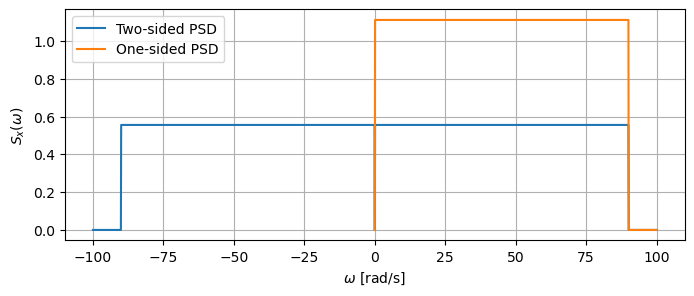

In [1]:
import numpy as np
from matplotlib import pyplot as plt

domega_plot = 0.1
omega_max_plot = 100.0
omega = np.arange(0.0, omega_max_plot + domega_plot, domega_plot)
omega_two = np.arange(-omega_max_plot, omega_max_plot + domega_plot, domega_plot)

omega_up = 90.0  # Upper cut-off frequency [rad/s]
sigma_x = 10.0   # Standard deviation

# One-sided PSD
S_wn = np.zeros_like(omega)
S_wn[(omega > 0) & (omega <= omega_up)] = sigma_x**2 / omega_up

plt.figure(figsize=(8, 3))
plt.plot(omega_two, 0.5 * np.interp(np.abs(omega_two), omega, S_wn),
         color='tab:blue', label='Two-sided PSD')
plt.plot(omega, S_wn, color='tab:orange', label='One-sided PSD')
plt.xlabel(r'$\omega$ [rad/s]')
plt.ylabel(r'$S_x(\omega)$')
plt.grid()
plt.legend()


The plot shows that this process consists of all frequencies (up to the cut-off frequency $\omega_{\mathrm{up}} \rightarrow \infty$). This makes it very broadbanded.

## Autocorrelation of white noise

The original Wiener–Khinchin relation is written using the two-sided PSD:

$$
R_x(\tau)=\int_{-\infty}^{\infty} S_x^{\text{two-sided}}(\omega)
\exp(i\omega\tau)\,\mathrm{d}\omega.
$$

For a real-valued process, the two-sided PSD is even. The contributions at positive and negative frequencies are therefore complex conjugates, so their imaginary parts cancel and their real parts combine into a cosine. The one-sided PSD contains the energy from both sides, $S_x(\omega)=2S_x^{\text{two-sided}}(\omega)$ for $\omega>0$. Consequently, the same autocorrelation is obtained from the one-sided PSD as

$$
R_x(\tau)=\int_0^\infty S_x(\omega)\cos(\omega\tau)\,\mathrm{d}\omega.
$$

We evaluate this integral numerically.


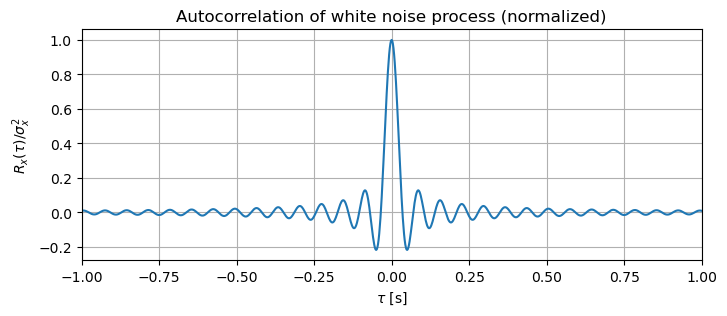

In [2]:
tau = np.arange(-2, 2, 0.002)  # Time-lag axis

R_wn = np.zeros_like(tau)
for k, tau_k in enumerate(tau):
    R_wn[k] = np.trapezoid(S_wn * np.cos(omega * tau_k), omega)

plt.figure(figsize=(8, 3))
plt.plot(tau, R_wn / sigma_x**2)
plt.title('Autocorrelation of white noise process (normalized)')
plt.ylabel(r'$R_x(\tau) / \sigma_x^2$')
plt.xlabel(r'$\tau$ [s]')
plt.xlim(-1, 1)
plt.grid()


## Simulated time series of white noise

We now use the spectral Monte Carlo method from Example 3.6 instead of constructing a covariance matrix. Choose an odd number of samples so that the discrete frequency grid is symmetric about zero. For the positive frequencies,

$$
A_k=\sqrt{2S_x(\omega_k)\Delta\omega},
\qquad
X_k=\frac{A_k}{2}e^{i\phi_k},
$$

where $\phi_k$ are independent uniform phase angles. NumPy's `irfft` supplies the conjugate negative-frequency coefficients. The factor $N$ accounts for NumPy's inverse-transform normalization.


Spectral standard deviation: 9.997
Realization standard deviation: 9.997


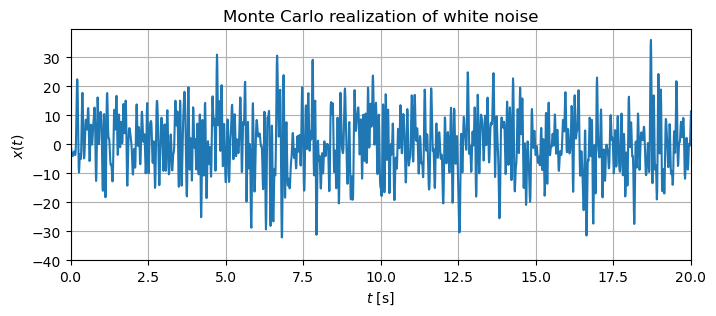

In [14]:
# Common time and frequency grids for the Monte Carlo simulations
dt = 0.01
T_requested = 60.01
N = int(T_requested / dt)

T = N * dt
t = np.arange(N) * dt
domega = 2 * np.pi / T
n_freq = (N + 1) // 2
omega_sim = np.arange(n_freq) * domega


def simulate_from_one_sided_psd(S):
    # Simulate one realization using the IRFFT method from Example 3.6.
    amplitudes = np.sqrt(2 * S * domega)
    amplitudes[0] = 0.0
    phases = np.random.uniform(0, 2 * np.pi, n_freq)
    coefficients = (amplitudes / 2) * np.exp(1j * phases)
    coefficients[0] = 0.0
    return N * np.fft.irfft(coefficients, n=N)


# Define the one-sided PSD directly on the simulation grid
S_sim = np.zeros_like(omega_sim)
S_sim[(omega_sim > 0) & (omega_sim <= omega_up)] = sigma_x**2 / omega_up
x_wn = simulate_from_one_sided_psd(S_sim)

plt.figure(figsize=(8, 3))
plt.plot(t, x_wn)
plt.title('Monte Carlo realization of white noise')
plt.ylabel(r'$x(t)$')
plt.xlabel(r'$t$ [s]')
plt.xlim(0, 20)
plt.grid()

print(f'Spectral standard deviation: {np.sqrt(np.sum(S_sim) * domega):.3f}')
print(f'Realization standard deviation: {np.std(x_wn):.3f}')


The realization is highly irregular because the white-noise PSD distributes its energy uniformly over a broad frequency range. The simulated standard deviation is governed by the area under the discretized one-sided PSD.


## Auto spectral density of a narrowbanded process

At the opposite extreme, consider a process whose PSD is non-zero only in a narrow interval between $\omega_1$ and $\omega_2$. Its one-sided PSD is

$$
S_x(\omega)=
\begin{cases}
\dfrac{\sigma_x^2}{\omega_2-\omega_1}, & \omega_1\leq\omega\leq\omega_2,\\
0, & \text{elsewhere}.
\end{cases}
$$


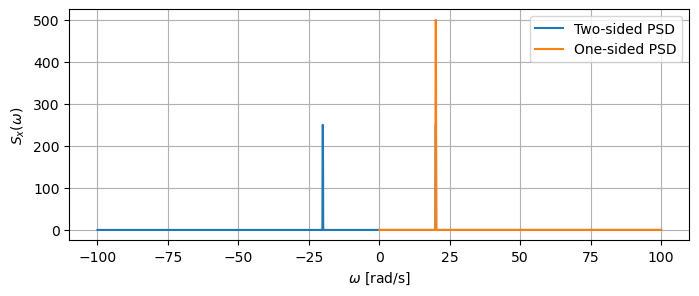

In [23]:
omega_1 = 20.0  # Lower cut-off frequency [rad/s]
omega_2 = 20.2  # Upper cut-off frequency [rad/s]

# One-sided PSD
S_nb = np.zeros_like(omega)
S_nb[(omega >= omega_1) & (omega <= omega_2)] = (
    sigma_x**2 / (omega_2 - omega_1)
)

plt.figure(figsize=(8, 3))
plt.plot(omega_two, 0.5 * np.interp(np.abs(omega_two), omega, S_nb),
         color='tab:blue', label='Two-sided PSD')
plt.plot(omega, S_nb, color='tab:orange', label='One-sided PSD')
plt.xlabel(r'$\omega$ [rad/s]')
plt.ylabel(r'$S_x(\omega)$')
plt.grid()
plt.legend()


## Autocorrelation of a narrowbanded process

The same relation between the one-sided PSD and the autocorrelation function is used for the narrowbanded process.


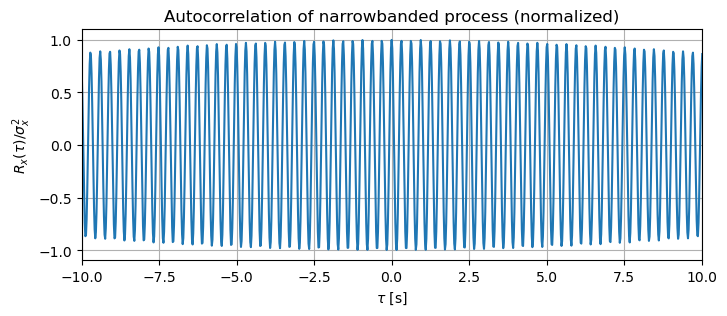

In [24]:
tau = np.arange(-20, 20, 0.02)  # Time-lag axis

R_nb = np.zeros_like(tau)
for k, tau_k in enumerate(tau):
    R_nb[k] = np.trapezoid(S_nb * np.cos(omega * tau_k), omega)

plt.figure(figsize=(8, 3))
plt.plot(tau, R_nb / sigma_x**2)
plt.title('Autocorrelation of narrowbanded process (normalized)')
plt.ylabel(r'$R_x(\tau) / \sigma_x^2$')
plt.xlabel(r'$\tau$ [s]')
plt.xlim(-10, 10)
plt.grid()


## Simulated time series of a narrowbanded process

The same IRFFT Monte Carlo method is now applied to the one-sided narrowband PSD. Try changing $\omega_1$ and $\omega_2$ to see how the bandwidth affects the realization.


Spectral standard deviation: 7.235
Realization standard deviation: 7.235


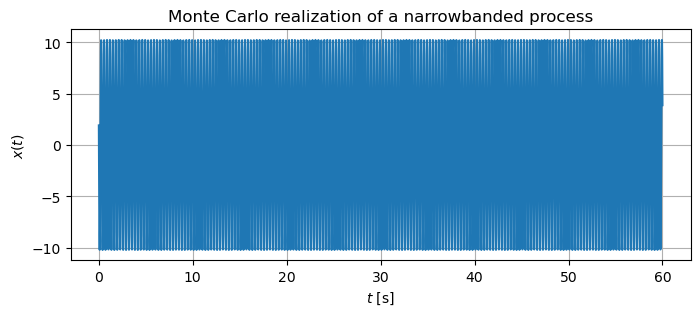

In [26]:
# Define the one-sided narrowband PSD directly on the simulation grid
S_sim = np.zeros_like(omega_sim)
S_sim[(omega_sim >= omega_1) & (omega_sim <= omega_2)] = (
    sigma_x**2 / (omega_2 - omega_1)
)
x_nb = simulate_from_one_sided_psd(S_sim)

plt.figure(figsize=(8, 3))
plt.plot(t, x_nb)
plt.title('Monte Carlo realization of a narrowbanded process')
plt.ylabel(r'$x(t)$')
plt.xlabel(r'$t$ [s]')
#plt.xlim(10,40)
plt.grid()

print(f'Spectral standard deviation: {np.sqrt(np.sum(S_sim) * domega):.3f}')
print(f'Realization standard deviation: {np.std(x_nb):.3f}')


The narrowbanded realization resembles a harmonic oscillation whose amplitude and phase evolve slowly. Unlike the covariance-matrix approach, the spectral simulation scales efficiently to long records and directly uses the prescribed one-sided PSD.
